# SIS Logistic Growth (No Vital Dynamics)

## Theory

In a **SIS model** infectious individuals recover but return to the susceptible pool
(no lasting immunity).  The ODEs are:

$$\frac{dS}{dt} = -\beta \frac{SI}{N} + \gamma I, \qquad
  \frac{dI}{dt} = +\beta \frac{SI}{N} - \gamma I$$

The **basic reproduction number** is $R_0 = \beta / \gamma$.

* If $R_0 > 1$ (β > γ): the disease reaches an **endemic equilibrium**
  $$I^* = N\left(1 - \frac{\gamma}{\beta}\right) = N\left(1 - \frac{1}{R_0}\right)$$
* If $R_0 \leq 1$ (β ≤ γ): the disease **dies out** and I → 0.

The transient path from I₀ to I* follows a generalized logistic shape.

**Goal:** Verify the endemic equilibrium numerically and demonstrate extinction when R₀ < 1.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from laser.core import PropertySet
from laser.core.utils import grid
from laser.generic.utils import ValuesMap
from laser.cohorts import Model
import laser.cohorts.SIS as SIS

In [2]:
# --- Parameters (R0 > 1 scenario) ---
N      = 50_000
I0     = 10
beta   = 0.3      # transmission rate (per day)
gamma  = 0.1      # recovery rate (per day)  →  R0 = 3
nticks = 200

# --- Scenario: only S and I (no R column for SIS) ---
scenario = grid(M=1, N=1)
scenario["S"] = N - I0
scenario["I"] = I0

# --- Build model ---
params = PropertySet({"nticks": nticks, "beta": beta, "r_recovery": gamma})
model  = Model(scenario, params)

betas       = ValuesMap.from_scalar(beta,  nticks, len(scenario))
r_recoveries = ValuesMap.from_scalar(gamma, nticks, len(scenario))

model.components = [
    SIS.Susceptible(model),
    SIS.Infectious(model,  r_recovery=r_recoveries),
    SIS.Transmission(model, beta=betas),
]

model.run()
print("Model run complete.")

Model run complete.


In [3]:
S = model.states.S[:, 0]
I = model.states.I[:, 0]

assert (S + I == N).all(), "Population conservation violated: S + I ≠ N"
print("S + I = N: OK")

S + I = N: OK


In [4]:
R0     = beta / gamma
I_star = N * (1 - gamma / beta)

print(f"R₀    = β/γ = {R0:.2f}")
print(f"I*    = N·(1 - 1/R₀) = {I_star:,.0f}  ({100*I_star/N:.1f}% of population)")
print(f"Final simulated I = {I[-1]:,}")

R₀    = β/γ = 3.00
I*    = N·(1 - 1/R₀) = 33,333  (66.7% of population)
Final simulated I = 34,171


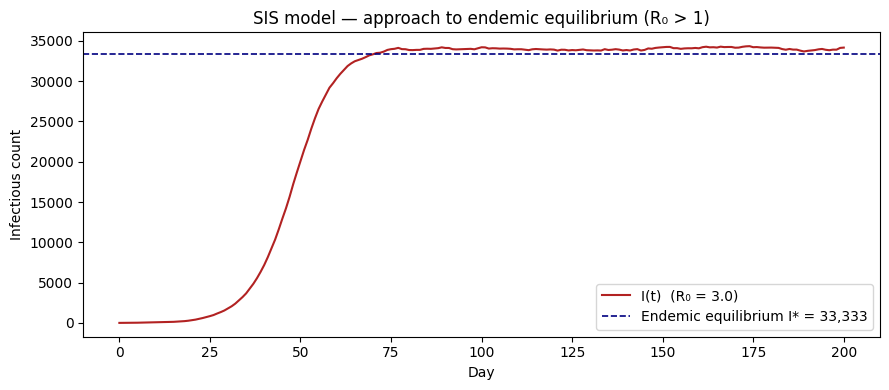

In [5]:
t = np.arange(nticks + 1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, I, color="firebrick", label=f"I(t)  (R₀ = {R0:.1f})")
ax.axhline(I_star, color="navy", linestyle="--", linewidth=1.2,
           label=f"Endemic equilibrium I* = {I_star:,.0f}")
ax.set_xlabel("Day")
ax.set_ylabel("Infectious count")
ax.set_title("SIS model — approach to endemic equilibrium (R₀ > 1)")
ax.legend()
plt.tight_layout()
plt.show()

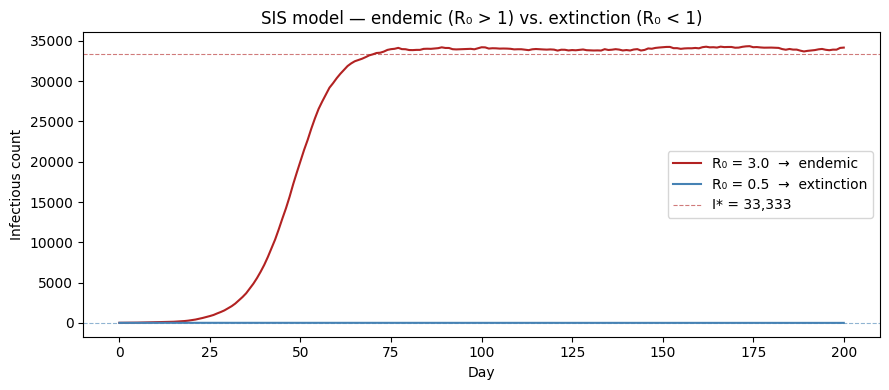

Final I (R₀ = 3.0): 34,171  ≈ I* = 33,333
Final I (R₀ = 0.5): 0  (disease extinct)


In [6]:
# --- Demonstrate extinction when R0 < 1 ---
beta2  = 0.05   # R0 = 0.5 < 1  →  disease dies out

scenario2 = grid(M=1, N=1)
scenario2["S"] = N - I0
scenario2["I"] = I0

params2  = PropertySet({"nticks": nticks, "beta": beta2, "r_recovery": gamma})
model2   = Model(scenario2, params2)

betas2       = ValuesMap.from_scalar(beta2, nticks, len(scenario2))
r_recoveries2 = ValuesMap.from_scalar(gamma, nticks, len(scenario2))

model2.components = [
    SIS.Susceptible(model2),
    SIS.Infectious(model2,  r_recovery=r_recoveries2),
    SIS.Transmission(model2, beta=betas2),
]
model2.run()

I2   = model2.states.I[:, 0]
R0_2 = beta2 / gamma

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, I,  color="firebrick", label=f"R₀ = {R0:.1f}  →  endemic")
ax.plot(t, I2, color="steelblue", label=f"R₀ = {R0_2:.1f}  →  extinction")
ax.axhline(I_star, color="firebrick", linestyle="--", linewidth=0.8, alpha=0.6,
           label=f"I* = {I_star:,.0f}")
ax.axhline(0, color="steelblue", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_xlabel("Day")
ax.set_ylabel("Infectious count")
ax.set_title("SIS model — endemic (R₀ > 1) vs. extinction (R₀ < 1)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Final I (R₀ = {R0:.1f}): {I[-1]:,}  ≈ I* = {I_star:,.0f}")
print(f"Final I (R₀ = {R0_2:.1f}): {I2[-1]:,}  (disease extinct)")